In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_matches = pd.read_csv('../../data/preprocessed/preprocessed_1.csv')
df_matches = pd.read_csv('../../data/preprocessed/preprocessed_1.csv')
df_matches.sort_values(by=["season", "stage", "date"], inplace=True)

In [3]:
from xgboost import XGBClassifier
from sklearn.metrics import f1_score


def train_and_evaluate(train_df, val_df, test_df, season, stage):
    feature_cols = [col for col in train_df.columns if col not in
                    ["match_api_id", "result_match", "season", "stage", "date", "home_team", "away_team"]]

    X_train = train_df[feature_cols]
    y_train = train_df["result_match"]

    X_val = val_df[feature_cols]
    y_val = val_df["result_match"]

    X_test = test_df[feature_cols]
    y_test = test_df["result_match"]

    params = {'colsample_bytree': 0.9122037146636167,
              'gamma': 2.4661605714698633,
              'learning_rate': 0.28232271227973194,
              'max_depth': 11,
              'min_child_weight': 14.537590110684029,
              'n_estimators': 350,
              'reg_alpha': 0.0016649737789195714,
              'reg_lambda': 0.041539687486306605,
              'subsample': 0.87996475056957}

    y_train_value_counts = y_train.value_counts()
    ratio = y_train_value_counts[0] / y_train_value_counts[1]

    model = XGBClassifier(
        **params,
        random_state=42,
        use_label_encoder=False,
        eval_metric="logloss",
        scale_pos_weight=ratio
    )

    model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=False)

    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)

    f1 = f1_score(y_test, y_pred)

    test_indices = test_df.index.tolist()

    misclassified_info = []
    for i, (true, pred) in enumerate(zip(y_test, y_pred)):
        if true != pred:
            misclassified_info.append({
                'index': test_indices[i],
                'true_label': true,
                'predicted_label': pred,
                'confidence': y_pred_proba[i][pred],
                'match_id': test_df.iloc[i]['match_api_id'] if 'match_api_id' in test_df.columns else None
            })

    # Get feature importance
    feature_importance = {feature: importance for feature, importance in
                          zip(feature_cols, model.feature_importances_)}

    return f1, season, stage, y_test.tolist(), y_pred.tolist(), misclassified_info, feature_importance, test_indices, y_pred_proba.tolist()

In [4]:
# ---------------------
# Backtesting over multiple seasons
# ---------------------

seasons = sorted(df_matches["season"].unique(), reverse=True)
backtest_results = []
all_misclassifications = []  # Store all misclassification details

for i in range(1, len(seasons)):
    target_season = seasons[0]
    previous_seasons = seasons[1:1 + i]

    target_season_df = df_matches[df_matches["season"] == target_season]
    target_stages = sorted(target_season_df["stage"].unique())

    for stage in target_stages:
        if stage <= min(target_stages) + 1:
            continue

        train_df_prev = df_matches[df_matches["season"].isin(previous_seasons)]
        train_df_target = target_season_df[target_season_df["stage"] < (stage - 1)]
        train_df = pd.concat([train_df_prev, train_df_target], ignore_index=True)

        val_df = target_season_df[target_season_df["stage"] == (stage - 1)]
        test_df = target_season_df[target_season_df["stage"] == stage]

        if train_df.empty or val_df.empty or test_df.empty:
            continue

        # Use the updated train_and_evaluate function with more return values
        f1, season, stage, y_test, y_pred, misclassified_info, feature_importance, test_indices, y_pred_proba = train_and_evaluate(
            train_df, val_df, test_df, target_season, stage
        )

        backtest_results.append({
            "season": f"{season} - {len(previous_seasons)}",
            "stage": stage,
            "train_size": len(train_df),
            "f1_score": f1,
            "y_test": y_test,
            "y_pred": y_pred,
            "feature_importance": feature_importance
        })

        # Add context to misclassification info
        for item in misclassified_info:
            item["season_context"] = f"{season} - {len(previous_seasons)}"
            item["stage"] = stage
            all_misclassifications.append(item)

results_df = pd.DataFrame(backtest_results)
misclassifications_df = pd.DataFrame(all_misclassifications)

print("Backtesting results for each season and stage:")
results_df.to_csv('stages_results.csv', index=False)
results_df

Backtesting results for each season and stage:


,season,stage,train_size,f1_score,y_test,y_pred,feature_importance
0,2015/2016 - 1,3,379,1.000000,"[1, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 0, 0, 0, 0, 0, 0, 0, 0]","{'points_home': 0.017247453, 'points_away': 0...."
1,2015/2016 - 1,4,387,0.444444,"[0, 0, 0, 0, 1, 0, 0, 0, 1, 1]","[1, 1, 0, 0, 1, 0, 1, 1, 0, 1]","{'points_home': 0.017247453, 'points_away': 0...."
2,2015/2016 - 1,5,396,0.600000,"[0, 1, 1, 0, 1, 1, 1, 1, 0, 1]","[0, 0, 1, 0, 0, 1, 1, 0, 0, 0]","{'points_home': 0.017247453, 'points_away': 0...."
3,2015/2016 - 1,6,406,0.363636,"[0, 0, 0, 0, 1, 1, 0, 0, 0, 1]","[1, 1, 1, 1, 0, 1, 1, 1, 0, 1]","{'points_home': 0.017247453, 'points_away': 0...."
4,2015/2016 - 1,7,416,0.727273,"[0, 1, 1, 1, 1, 1, 0, 0, 0, 0]","[0, 1, 1, 1, 0, 1, 1, 0, 0, 1]","{'points_home': 0.017247453, 'points_away': 0...."
...,...,...,...,...,...,...,...
247,2015/2016 - 7,34,2915,0.333333,"[0, 0, 0, 1, 1, 0, 0, 0, 0, 0]","[0, 0, 1, 0, 1, 0, 1, 0, 1, 0]","{'points_home': 0.017247453, 'points_away': 0...."
248,2015/2016 - 7,35,2925,0.666667,"[0, 0, 0, 0, 1, 0, 1, 0, 1, 1]","[0, 0, 0, 1, 1, 0, 0, 1, 1, 1]","{'points_home': 0.017247453, 'points_away': 0...."
249,2015/2016 - 7,36,2935,0.363636,"[1, 1, 1, 0, 1, 0, 1, 1, 0, 0]","[1, 0, 0, 1, 1, 1, 0, 0, 1, 0]","{'points_home': 0.017247453, 'points_away': 0...."
250,2015/2016 - 7,37,2945,0.444444,"[0, 0, 1, 1, 0, 1, 0, 0, 1, 0]","[0, 1, 0, 1, 0, 0, 1, 1, 1, 0]","{'points_home': 0.017247453, 'points_away': 0...."


In [5]:
misclassifications_df.to_csv('misclassifications_df.csv', index=False)
misclassifications_df

,index,true_label,predicted_label,confidence,match_id,season_context,stage
0,2626,0,1,0.660833,1988740,2015/2016 - 1,4
1,2627,0,1,0.587579,1988741,2015/2016 - 1,4
2,2632,0,1,0.644300,1988747,2015/2016 - 1,4
3,2633,0,1,0.700940,1988749,2015/2016 - 1,4
4,2634,1,0,0.655853,1988746,2015/2016 - 1,4
...,...,...,...,...,...,...,...
1017,2961,0,1,0.870841,1989079,2015/2016 - 7,37
1018,2962,0,1,0.886562,1989078,2015/2016 - 7,37
1019,2965,1,0,0.666588,1987603,2015/2016 - 7,38
1020,2966,0,1,0.509937,1987605,2015/2016 - 7,38


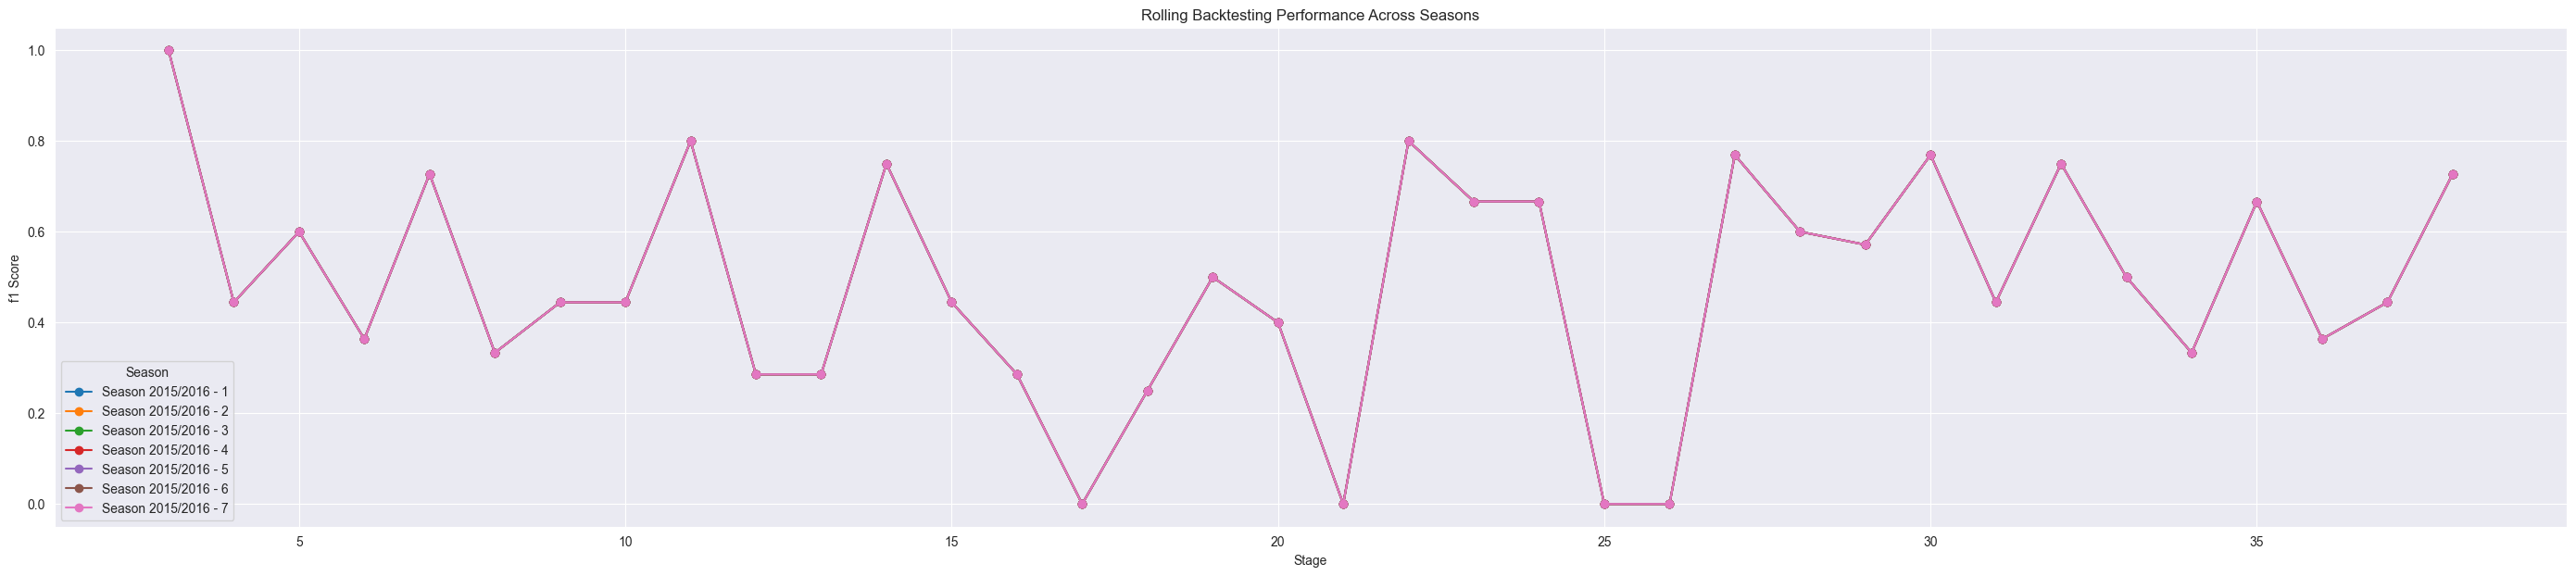

In [11]:
plt.figure(figsize=(35, 7))
for season in results_df["season"].unique():
    season_results = results_df[results_df["season"] == season]
    plt.plot(season_results["stage"], season_results["f1_score"], marker="o", label=f"Season {season}")

plt.xlabel("Stage")
plt.ylabel("f1 Score")
plt.title("Rolling Backtesting Performance Across Seasons")
plt.legend(title="Season")
plt.grid(True)
plt.show()

In [13]:
avg_results = results_df.groupby("season")["f1_score"].mean().reset_index()
avg_results.rename(columns={"f1_score": "avg_f1_score"}, inplace=True)
print("\nAverage f1 Score for each season:")
print(avg_results)

plt.figure(figsize=(12, 6))
plt.bar(avg_results["season"].astype(str), avg_results["avg_f1_score"], color='skyblue')
plt.xlabel("Season")
plt.ylabel("Average f1 Score")
plt.title("Average f1 Score per Season")
plt.grid(axis='y')
plt.show()

KeyboardInterrupt: 

In [8]:
results_df[results_df["season"] == '2015/2016 - 3']

,season,stage,train_size,f1_score,y_test,y_pred,feature_importance
72,2015/2016 - 3,3,1131,1.000000,"[1, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 0, 0, 0, 0, 0, 0, 0, 0]","{'points_home': 0.017247453, 'points_away': 0...."
73,2015/2016 - 3,4,1139,0.444444,"[0, 0, 0, 0, 1, 0, 0, 0, 1, 1]","[1, 1, 0, 0, 1, 0, 1, 1, 0, 1]","{'points_home': 0.017247453, 'points_away': 0...."
74,2015/2016 - 3,5,1148,0.600000,"[0, 1, 1, 0, 1, 1, 1, 1, 0, 1]","[0, 0, 1, 0, 0, 1, 1, 0, 0, 0]","{'points_home': 0.017247453, 'points_away': 0...."
75,2015/2016 - 3,6,1158,0.363636,"[0, 0, 0, 0, 1, 1, 0, 0, 0, 1]","[1, 1, 1, 1, 0, 1, 1, 1, 0, 1]","{'points_home': 0.017247453, 'points_away': 0...."
76,2015/2016 - 3,7,1168,0.727273,"[0, 1, 1, 1, 1, 1, 0, 0, 0, 0]","[0, 1, 1, 1, 0, 1, 1, 0, 0, 1]","{'points_home': 0.017247453, 'points_away': 0...."
77,2015/2016 - 3,8,1178,0.333333,"[0, 0, 0, 1, 1, 0, 0, 0, 0, 1]","[0, 1, 0, 0, 1, 0, 0, 0, 1, 0]","{'points_home': 0.017247453, 'points_away': 0...."
78,2015/2016 - 3,9,1188,0.444444,"[1, 1, 0, 0, 1, 0, 0, 0, 1, 0]","[0, 1, 1, 0, 1, 0, 1, 0, 0, 1]","{'points_home': 0.017247453, 'points_away': 0...."
79,2015/2016 - 3,10,1198,0.444444,"[1, 0, 1, 0, 0, 1, 0, 0, 0, 1]","[1, 0, 0, 1, 0, 1, 1, 1, 0, 0]","{'points_home': 0.017247453, 'points_away': 0...."
80,2015/2016 - 3,11,1208,0.800000,"[1, 0, 0, 0, 1, 0, 0, 1, 1, 1]","[0, 0, 0, 1, 1, 0, 0, 1, 1, 1]","{'points_home': 0.017247453, 'points_away': 0...."
81,2015/2016 - 3,12,1218,0.285714,"[0, 0, 1, 1, 1, 1, 0, 0, 0, 0]","[0, 0, 1, 0, 0, 0, 0, 1, 0, 1]","{'points_home': 0.017247453, 'points_away': 0...."
